Тренировочный датасет: 132000 строк
Тестовый датасет: 10000 строк


Входные параметры уравнения Больцмана:

*   E(напряженность эл. поля: 100 точек от 1 до 500 Тд, равномерная шкала, Таунсенд = 1 Тд = 10-21 В·м^2)
*   T (температура возбуждения: 20 точек от 1000 до 6000K, равномерная шкала)
*   fraction_of_Ar, fraction_of_He, fraction_of_H2 (концентрации газов аргона, гелия и водорода в смеси: 11 точек от 0.0 до 1.0 с шагом 0.1)

В уравнении также присутствует множество других параметров, но при формировании датасетов они были зафиксированы

В качестве **таргетов**, которые можно предсказывать как вместе, так и по отдельности, подготовлены средняя энергия частиц (mean_Energy) и частота импульсов (momentum_freq)



**Задача**: научиться предсказывать среднюю энергию/частоту импульсов с высокой точностью по набору концентраций газов вместе с напряженностью эл.поля и температурой возбуждения.
Сетка параметров-признаков разбита равномерно => в качестве отправной точности, с которой можно сравнивать метрики моделей стоит рассмотреть аппроксиматор внутри "ячейки сетки"
параметров (научиться определять к какой ячейке относится предсказываемая точка и вычислить значение пропорционально расстоянию до узлов ячейки (KNN). Или брать несколько сосендних
ячеек и сделать интерполяцию)

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor

In [43]:

df = pd.read_csv('/content/train_df_Ar_He_H2.csv')
df.drop(columns=['Unnamed: 0'], inplace=True)
df.head()

,E,T,Fraction_of_Ar,Fraction_of_He,Fraction_of_H2,mean_Energy,momentum_freq
0,1.0,1000.0,0.0,0.0,1.0,0.1740,3.500000e-14
1,1.0,1000.0,0.0,0.1,0.9,0.1804,3.428000e-14
2,1.0,1000.0,0.0,0.2,0.8,0.1880,3.358000e-14
3,1.0,1000.0,0.0,0.3,0.7,0.1971,3.293000e-14
4,1.0,1000.0,0.0,0.4,0.6,0.2081,3.233000e-14


In [44]:
df_test = pd.read_csv('/content/test_df_Ar_He_H2.csv')
df_test.drop(columns=['Unnamed: 0'], inplace=True)
df_test.head()

,E,T,Fraction_of_Ar,Fraction_of_He,Fraction_of_H2,mean_Energy,momentum_freq
0,286.073438,5718.986448,0.274998,0.663509,0.061493,11.850,1.336000e-13
1,144.773051,4752.428608,0.747931,0.044045,0.208024,7.014,1.989000e-13
2,291.599257,3254.699803,0.283429,0.212264,0.504307,9.304,1.508000e-13
3,65.350987,2708.512932,0.004005,0.812303,0.183692,6.522,8.991000e-14
4,112.939360,3356.937449,0.472025,0.358469,0.169505,6.925,1.583000e-13


In [45]:
X_train = df.drop(columns=['mean_Energy', 'momentum_freq'])

In [46]:
y_mean_energy_train = df['mean_Energy']

In [47]:
y_momentum_freq_train = df['momentum_freq']

In [48]:
X_test = df_test.drop(columns=['mean_Energy', 'momentum_freq'])
y_mean_energy_test = df_test['mean_Energy']
y_momentum_freq_test = df_test['momentum_freq']

In [49]:
# Модель KNN для предсказания средней энергии
knn_mean_energy = KNeighborsRegressor(n_neighbors=5)
knn_mean_energy.fit(X_train, y_mean_energy_train)
y_mean_energy_pred_knn = knn_mean_energy.predict(X_test)
mse_mean_energy_knn = mean_squared_error(y_mean_energy_test, y_mean_energy_pred_knn)
print(f"KNN Mean Squared Error (Mean Energy): {mse_mean_energy_knn}")

# Модель KNN для предсказания частоты импульсов
knn_momentum_freq = KNeighborsRegressor(n_neighbors=5) # Выберите оптимальное количество соседей
knn_momentum_freq.fit(X_train, y_momentum_freq_train)
y_momentum_freq_pred_knn = knn_momentum_freq.predict(X_test)
mse_momentum_freq_knn = mean_squared_error(y_momentum_freq_test, y_momentum_freq_pred_knn)
print(f"KNN Mean Squared Error (Momentum Frequency): {mse_momentum_freq_knn}")

KNN Mean Squared Error (Mean Energy): 0.15054018630064
KNN Mean Squared Error (Momentum Frequency): 2.632324763359999e-29


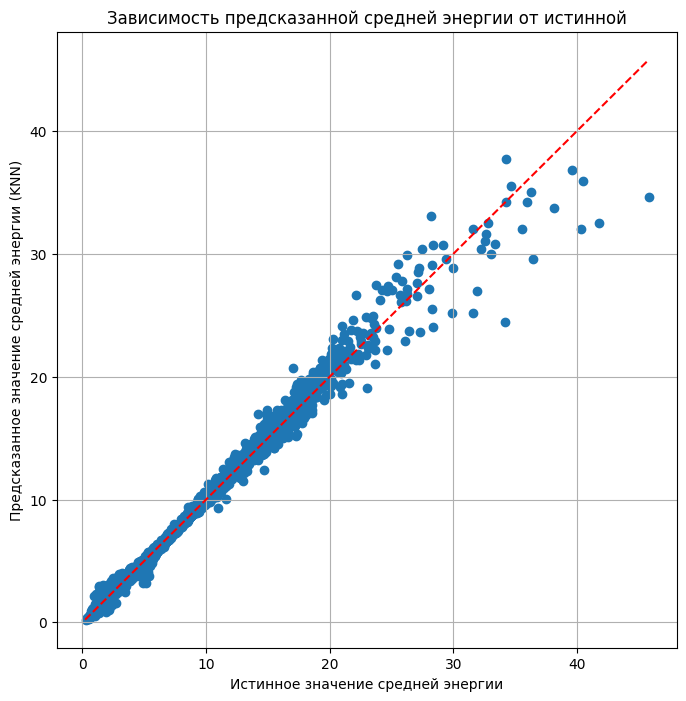

In [50]:
import matplotlib.pyplot as plt
import numpy as np


plt.figure(figsize=(8, 8))
plt.scatter(y_mean_energy_test, y_mean_energy_pred_knn)

# Добавим диагональную линию для идеальных предсказаний
min_val = min(np.min(y_mean_energy_test), np.min(y_mean_energy_pred_knn))
max_val = max(np.max(y_mean_energy_test), np.max(y_mean_energy_pred_knn))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.xlabel('Истинное значение средней энергии')
plt.ylabel('Предсказанное значение средней энергии (KNN)')
plt.title('Зависимость предсказанной средней энергии от истинной')
plt.grid(True)
plt.show()

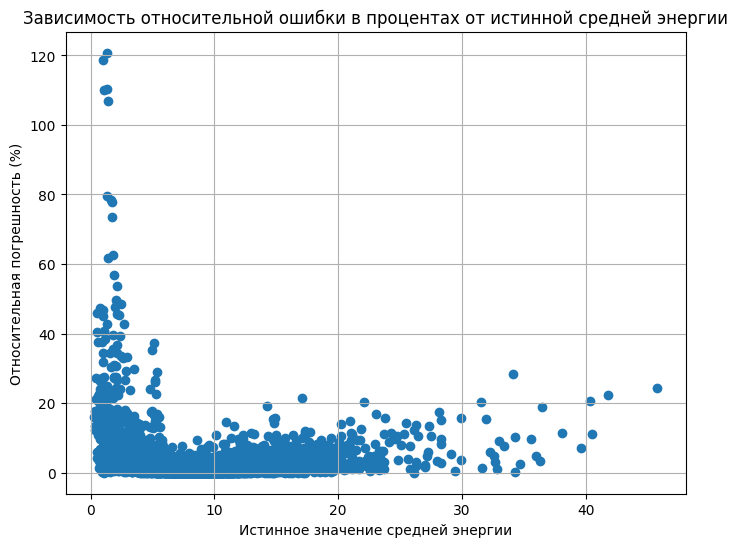

In [56]:
import matplotlib.pyplot as plt
import numpy as np


# Расчет относительной погрешности в процентах
relative_error_percent = np.abs((y_mean_energy_pred_knn - y_mean_energy_test) / y_mean_energy_test) * 100

plt.figure(figsize=(8, 6))
plt.scatter(y_mean_energy_test, relative_error_percent)

plt.xlabel('Истинное значение средней энергии')
plt.ylabel('Относительная погрешность (%)')
plt.title('Зависимость относительной ошибки в процентах от истинной средней энергии')
plt.grid(True)
plt.show()

In [51]:
from sklearn.preprocessing import Normalizer

# Инициализация нормализатора
normalizer = Normalizer()

# Обучение нормализатора на тренировочных данных и их преобразование
X_train_normalized = normalizer.fit_transform(X_train)

# Преобразование тестовых данных с использованием обученного нормализатора
X_test_normalized = normalizer.transform(X_test)

# Модель KNN для предсказания средней энергии на нормализованных данных
knn_mean_energy_normalized = KNeighborsRegressor(n_neighbors=5)
knn_mean_energy_normalized.fit(X_train_normalized, y_mean_energy_train)
y_mean_energy_pred_knn_normalized = knn_mean_energy_normalized.predict(X_test_normalized)
mse_mean_energy_knn_normalized = mean_squared_error(y_mean_energy_test, y_mean_energy_pred_knn_normalized)
print(f"KNN Mean Squared Error (Mean Energy) с нормализацией: {mse_mean_energy_knn_normalized}")

# Модель KNN для предсказания частоты импульсов на нормализованных данных
knn_momentum_freq_normalized = KNeighborsRegressor(n_neighbors=5)
knn_momentum_freq_normalized.fit(X_train_normalized, y_momentum_freq_train)
y_momentum_freq_pred_knn_normalized = knn_momentum_freq_normalized.predict(X_test_normalized)
mse_momentum_freq_knn_normalized = mean_squared_error(y_momentum_freq_test, y_momentum_freq_pred_knn_normalized)
print(f"KNN Mean Squared Error (Momentum Frequency) с нормализацией: {mse_momentum_freq_knn_normalized}")

KNN Mean Squared Error (Mean Energy) с нормализацией: 6.0382879515042
KNN Mean Squared Error (Momentum Frequency) с нормализацией: 2.5751708355639997e-28


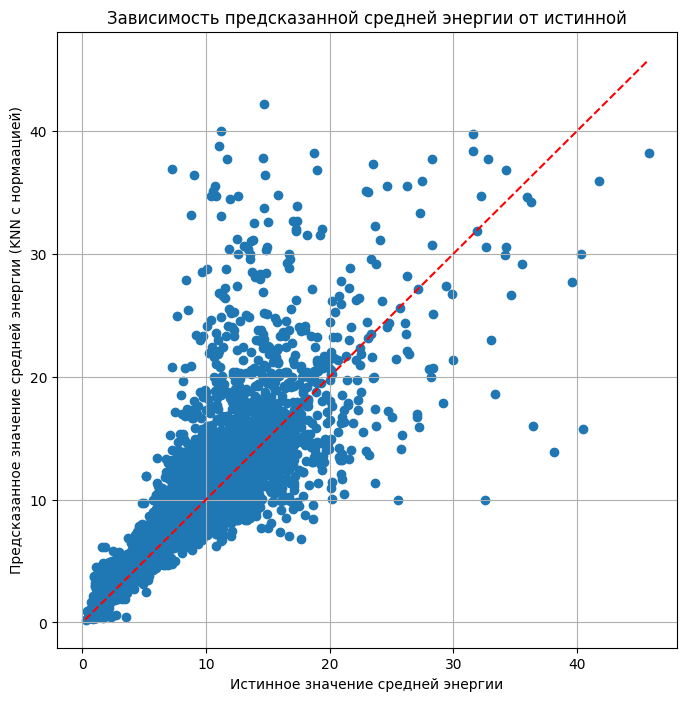

In [52]:
import matplotlib.pyplot as plt
import numpy as np


plt.figure(figsize=(8, 8))
plt.scatter(y_mean_energy_test, y_mean_energy_pred_knn_normalized)

# Добавим диагональную линию для идеальных предсказаний
min_val = min(np.min(y_mean_energy_test), np.min(y_mean_energy_pred_knn_normalized))
max_val = max(np.max(y_mean_energy_test), np.max(y_mean_energy_pred_knn_normalized))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.xlabel('Истинное значение средней энергии')
plt.ylabel('Предсказанное значение средней энергии (KNN с нормаацией)')
plt.title('Зависимость предсказанной средней энергии от истинной')
plt.grid(True)
plt.show()

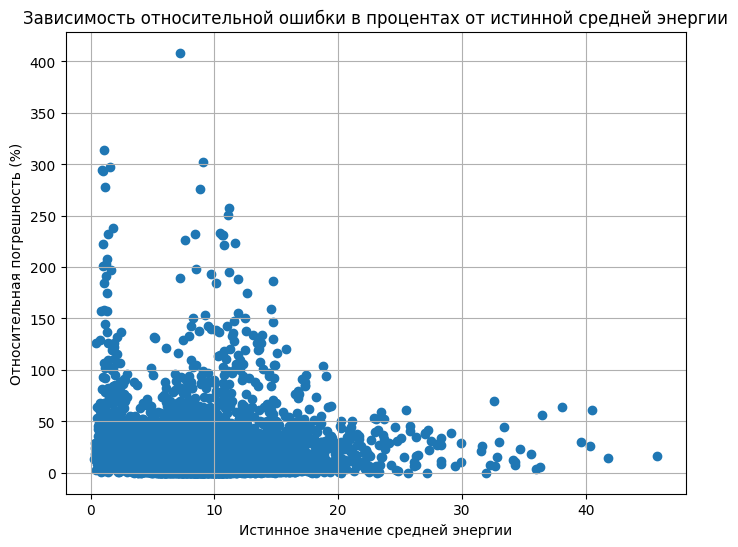

In [55]:
import matplotlib.pyplot as plt
import numpy as np


# Расчет относительной погрешности в процентах
relative_error_percent = np.abs((y_mean_energy_pred_knn_normalized - y_mean_energy_test) / y_mean_energy_test) * 100

plt.figure(figsize=(8, 6))
plt.scatter(y_mean_energy_test, relative_error_percent)

plt.xlabel('Истинное значение средней энергии')
plt.ylabel('Относительная погрешность (%)')
plt.title('Зависимость относительной ошибки в процентах от истинной средней энергии')
plt.grid(True)
plt.show()